# Imports 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

c:\Users\Refai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\__init__.py:15: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  from scipy.sparse import issparse


## Utility Functions
- Function for Train Data and Calculate Loss
- Function for plotting Curves 

In [2]:
def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=1000, lr=0.001, weight_decay=0):
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

- plot curve function that plot training loss on x-axis and validation loss on y-axis

In [3]:
def plot_curves(train_losses, val_losses, title):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

## Loading Data of California Housing Prices

In [4]:
data = fetch_california_housing()

X = data.data
y = data.target.reshape(-1, 1)

# Step 1 Using Few DataSamples

In [5]:
# Few samples
X_small = X[:2]
y_small = y[:2]

X_train, X_val, y_train, y_val = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

### Scaling Data

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [7]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

### Train Simple Model with a 2 Sample of DataSet

In [8]:
class SimpleModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

model = SimpleModel(X_train.shape[1])

train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=1000, lr=0.01
)

### Plotting Curve of Epochs Vs MSE Loss
- we used 2 samples only with a simple model having (one layer) and 
from graph the training MSE is much lower wrt the validation MSE 

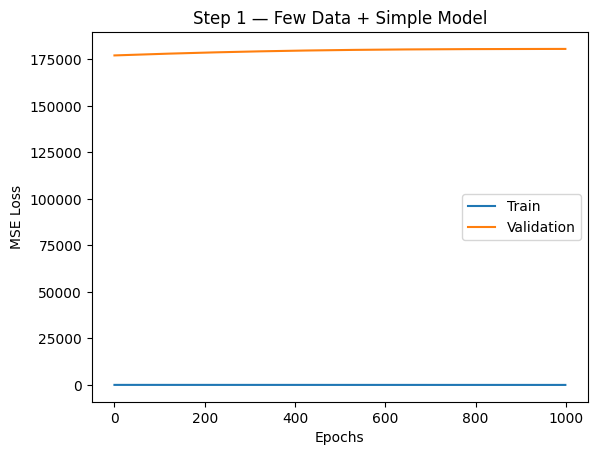

In [9]:
plot_curves(train_losses, val_losses, 
            "Step 1 — Few Data + Simple Model")


# Step 2 — Baseline 
Using a Simple Model for the whole Dataset with a simple model to Test the Underfitting  

Spitting Data

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.33, random_state=42
)

Scaling Data

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

Train Model

In [38]:
model = SimpleModel(X_train.shape[1])

train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=100, lr=0.001
)

### Visualize Data to See Underfitting
- we see that both training and validation error are large which means that the model is underfitted 

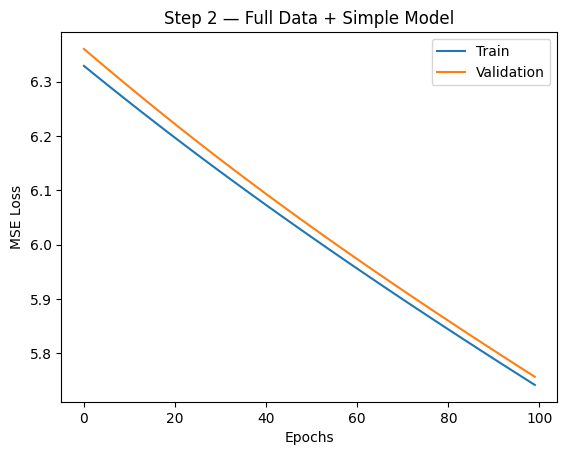

In [39]:
plot_curves(train_losses, val_losses, 
            "Step 2 — Full Data + Simple Model")
#we used a simple model with the full dataset to test underfitting of the model

# Step 3 — Reduce Bias
Use a Complex Model to solve the Underfitting Problem


In [35]:
class ComplexModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ComplexModel(X_train.shape[1])

Split Data

In [31]:
train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=1000, lr=0.1
)

- we have solved the underfitting problem but we encounter overfitting.

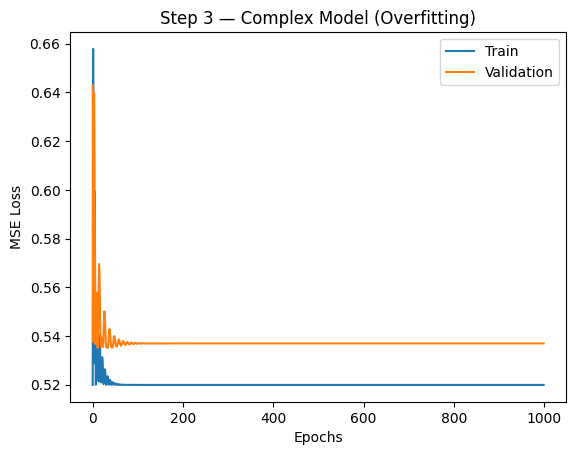

In [32]:
plot_curves(train_losses, val_losses, 
            "Step 3 — Complex Model (Overfitting)")
#here we used a complex model to see the overfitting 

# Step 4 — Regularization
- Reduce Complexity and Generalize the model 
- we wil use a regularization model to avoid both (overfitting and underfitting) as we will discuss later 

In [33]:
class RegularizedModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RegularizedModel(X_train.shape[1])

Split Data

In [34]:
train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=1000, lr=0.001, weight_decay=1e-4
)

- from the following graph we will see that the model performance is good
- and training error and validation error are both small and near to each other 

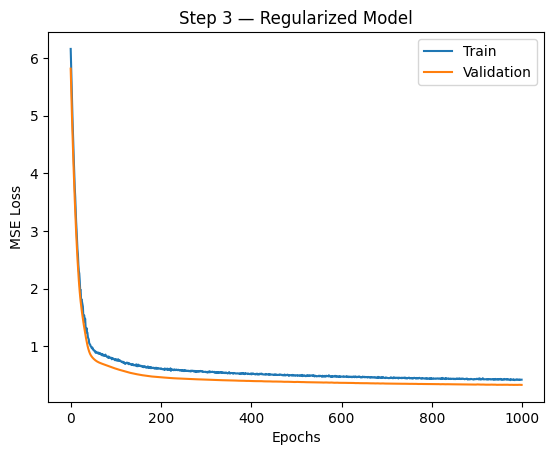

In [35]:
plot_curves(train_losses, val_losses, 
            "Step 3 — Regularized Model")
#using a regularization method to regulrize model to reduce overfitting and generlize model 